In [2]:
from pathlib import Path
import sys
_project_root = Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import KDTree
from scipy.spatial import distance_matrix
from scipy.optimize import minimize_scalar
from src.coordinates import sph_to_cart 


In [ ]:
N = 200
phi = (1+np.sqrt(5))/2
epsilon = 0
indices = np.linspace(0, N, N+1)
X = (indices/phi)%1
Y = (indices + epsilon)/(N + 2 * epsilon)

def polar_to_cart(r, theta):
	return r * np.cos(theta), r * np.sin(theta)

def generate_points(epsilon):
	X = (indices / phi) % 1
	Y = (indices + epsilon) / (N + 2 * epsilon)
	r = np.sqrt(Y)
	theta = 2 * np.pi * X
	x, y = polar_to_cart(r, theta)
	return np.vstack((x, y)).T

def generate_points2(epsilon):
	X = (indices / phi) % 1
	Y = (indices + epsilon) / (N + 2 * epsilon)

	theta = 2 * np.pi * X
	p = np.arccos(1-2*Y)
	coords = np.vstack((theta, p)).T
	return sph_to_cart(coords)

def objective(epsilon):
	points = generate_points(epsilon)
	dist_matrix = distance_matrix(points, points)
	# To avoid zero distance (distance of a point with itself), set diagonal to infinity
	np.fill_diagonal(dist_matrix, np.inf)
	min_dist = np.min(dist_matrix)
	return -min_dist


def objective2(epsilon):
	points = generate_points2(epsilon)
	dist_matrix = distance_matrix(points, points)
	# To avoid zero distance (distance of a point with itself), set diagonal to infinity
	np.fill_diagonal(dist_matrix, np.inf)
	min_dist = np.min(dist_matrix)
	return -min_dist

result = minimize_scalar(objective, bounds=(0.01, 4), method='bounded')
optimal_epsilon = result.x
print(f"Optimal epsilon: {optimal_epsilon}")
result = minimize_scalar(objective2, bounds=(0.01, 4), method='bounded')
optimal_epsilon = result.x
print(f"Optimal epsilon: {optimal_epsilon}")

Optimal epsilon: 1.6953976825101154
Optimal epsilon: 2.517226792965914


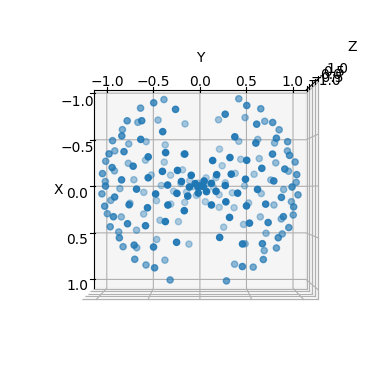

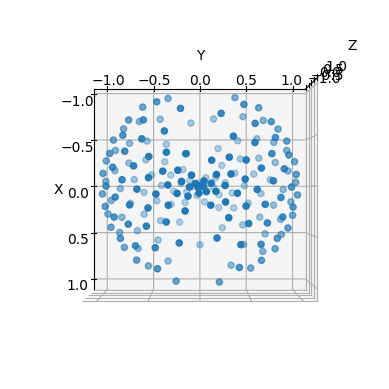

In [6]:
points = generate_points2(1.7744809502331707)
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(*points.T)
ax.set_aspect("equal")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(90,90,90)
plt.show()
points = generate_points2(0)
ax = plt.figure().add_subplot(projection="3d")
ax.scatter(*points.T)
ax.set_aspect("equal")
ax.view_init(90,90,90)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

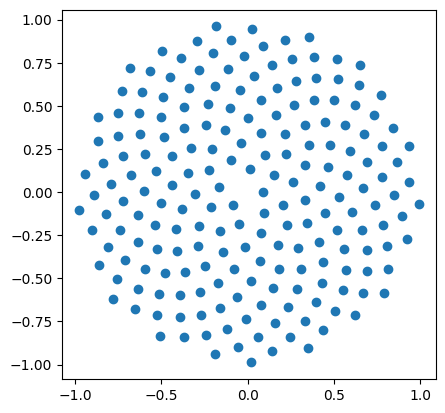

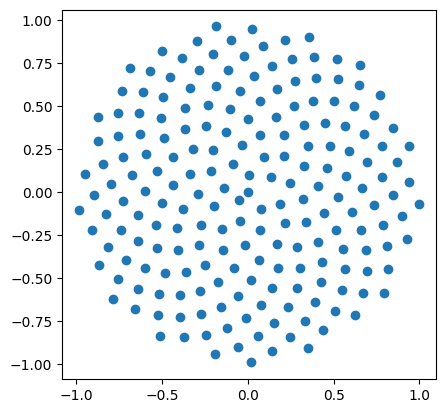

In [49]:
points = generate_points(1.6953976825101154)
fig, ax = plt.subplots()
ax.scatter(*points.T)
ax.set_aspect("equal")
plt.show()
points = generate_points(0)
fig, ax = plt.subplots()
ax.scatter(*points.T)
ax.set_aspect("equal")
plt.show()

In [1]:
fig, ax = plt.subplots()
ax.scatter(X.flatten(), Y.flatten())
ax.set_aspect("equal")
plt.show()
fig, ax = plt.subplots()
ax.scatter(*polar_to_cart(np.sqrt(Y), 2*np.pi*X))
ax.set_aspect("equal")
plt.show()
ax = plt.figure().add_subplot(projection="3d")
coords = np.vstack((2*np.pi*X, np.arccos(1-2*Y))).T
ax.scatter(*sph_to_cart(coords))
ax.set_aspect("equal")
plt.show()

NameError: name 'plt' is not defined